# **Notebook 2: SNP Data Cleaning**

This notebook imports the SNP feature matrix created with the Pipeline and performs preliminary data exploration and cleaning. 

**Overview:**
1. Load SNP genotypes and resistance phenotypes
2. Merge data on sample name
3. Remove low-prevalence SNPs (<2%)
4. Remove uninformative SNPs (>98% frequency)
6. Remove duplicate SNPs (identical across all samples)
7. Linkage disequilibrium pruning (remove highly correlated SNPs)
8. Select SNPs associated with resistance (chi-square test)
9. Save cleaned feature matrix ready for ML

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

# Set pastel color palette for plots
sns.set_palette("pastel")

## **0. Helper functions**
The function **parse_resistance_profile** is used to extract the resistance profiles from the genome_metadata.csv file.

In [3]:
def parse_resistance_profile(profile_str):
    """
    Parse resistance profile string into individual antibiotic phenotypes.
    
    Current format: "Resistant to X, Y; Susceptible to A, B; Intermediate to C; Not determined: D"
    Returns: dict with antibiotic: phenotype (R/S/I/ND)
    """
    phenotypes = {}
    
    if pd.isna(profile_str):
        return phenotypes
    
    # Split by semicolon to get phenotype groups
    parts = str(profile_str).split(';')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
            
        # Determine phenotype
        if part.startswith('Resistant to'):
            phenotype = 'R'
            antibiotics_str = part.replace('Resistant to', '').strip()
        elif part.startswith('Susceptible to'):
            phenotype = 'S'
            antibiotics_str = part.replace('Susceptible to', '').strip()
        elif part.startswith('Intermediate to'):
            phenotype = 'I'
            antibiotics_str = part.replace('Intermediate to', '').strip()
        elif part.startswith('Not determined'):
            phenotype = 'ND'
            antibiotics_str = part.replace('Not determined:', '').strip()
        else:
            continue
        
        # Split antibiotics by comma and add to dict
        antibiotics = [ab.strip() for ab in antibiotics_str.split(',')]
        for antibiotic in antibiotics:
            if antibiotic:
                phenotypes[antibiotic] = phenotype
    
    return phenotypes

## **1. Load and preprocess the data**
We first want to load the feature matrix (containing detected SNPs for all the strains) and a metadata file containing the resistance profile for all strains. 
We will then make sure that the strains in the feature matrix have a corresponding resistance profile.

In [7]:
# Define paths:
snp_tsv = "snps.tsv"
resistance_profiles = "../genome_metadata.csv"

### **1.1 Load SNP feature matrix and resistance profiles**

In [5]:
# Load SNP feature matrix (rows = samples, columns = SNPs)
snps_df = pd.read_csv(snp_tsv, sep='\t', index_col=0)
print(f"SNP feature matrix shape: {snps_df.shape}")
snps_df.head()

SNP feature matrix shape: (227, 78850)


,snp__NZ_AP028077.1_128_G_C,snp__NZ_AP028077.1_134_C_G,snp__NZ_AP028077.1_390_T_C,snp__NZ_AP028077.1_1158_G_A,snp__NZ_AP028077.1_1534_G_A,snp__NZ_AP028077.1_1549_G_A,snp__NZ_AP028077.1_2720_TG_CA,snp__NZ_AP028077.1_2721_G_A,snp__NZ_AP028077.1_2737_AG_A,snp__NZ_AP028077.1_2762_C_T,...,snp__NZ_AP028078.1_3143226_C_A,snp__NZ_AP028078.1_3143253_A_G,snp__NZ_AP028078.1_3143264_G_A,snp__NZ_AP028078.1_3143285_A_G,snp__NZ_AP028078.1_3143289_C_T,snp__NZ_AP028078.1_3143370_G_T,snp__NZ_AP028078.1_3143380_C_A,snp__NZ_AP028078.1_3143391_C_T,snp__NZ_AP028078.1_3143412_G_T,snp__NZ_AP028078.1_3143417_T_A
sample,,,,,,,,,,,,,,,,,,,,,
SRR3404582,0,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
SRR3404597,0,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
SRR3404599,0,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
SRR5927082,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
SRR6075123,0,0,0,0,0,0,0,0,1,0,...,0,1,1,1,0,0,0,0,0,0


In [8]:
# Load resistance profiles
resistances = pd.read_csv(resistance_profiles)
print(f"Sample metadata shape: {resistances.shape}")
resistances.head()

Sample metadata shape: (283, 5)


,genome_name,source,species,resistance_profile,sra_accession
0,EPAC004,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ; Not...",SRR27387708
1,EPAC006,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387706
2,EPAC013,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387705
3,EPAC021,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387702
4,EPAC023,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387701


### **1.2 Parse resistance profiles**
We will now parse the resistance profiles into a dictionary using the function parse_resistance_profile defined above. 
The list of dictionaries is then converted into a data frame which contains resistance information for each sample.

In [9]:
# Parse resistance profiles into a dictionary with antibiotic phenotypes
parsed_resistances = resistances['resistance_profile'].apply(parse_resistance_profile)
print(f"\nDictionary list structure: \n")
print(parsed_resistances.head())

# Convert list of dictionaries into a DataFrame
resistances_df = pd.json_normalize(parsed_resistances)
print(f"\nResistance data frame structure: \n")
print(resistances_df.head())

# Add sample name (sra_accession) to data frame and set is as index
resistances_df['sra_accession'] = resistances['sra_accession'].values
resistances_df = resistances_df.set_index('sra_accession')

print(f"\nResistance data frame shape: {resistances_df.shape}")


Dictionary list structure: 

0    {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'ND'}
1     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
2     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
3     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
4     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
Name: resistance_profile, dtype: object

Resistance data frame structure: 

  SXT AMC CAZ IPM  MEM   TZ TMEM/SMX
0   R   S   S  ND  NaN  NaN      NaN
1   R   S   S   S  NaN  NaN      NaN
2   R   S   S   S  NaN  NaN      NaN
3   R   S   S   S  NaN  NaN      NaN
4   R   S   S   S  NaN  NaN      NaN

Resistance data frame shape: (283, 7)


### **1.3 Find common samples between feature matrix and resistance profiles**
Let's now filter the SNP feature matrix and the resistance profile data frames so that they only contain common samples

In [10]:
# Find common samples between SNP data and resistance profile data and keep only common samples
# Start by removing duplicate entries
resistances_df = resistances_df.loc[~resistances_df.index.duplicated(keep='first')]
snps_df = snps_df.loc[~snps_df.index.duplicated(keep='first')]

# Find common samples
common_samples = snps_df.index.intersection(resistances_df.index)
print(f"\nCommon samples: {len(common_samples)} out of {len(snps_df)} SNP samples and {len(resistances_df)} samples with known resistance profiles")

# Keep only samples with both SNP and phenotype data
snps_df = snps_df.loc[common_samples]
resistances_df = resistances_df.loc[common_samples]

print(f"\nMerged data shape:")
print(f"SNPs: {snps_df.shape}")
print(f"Resistance profiles: {resistances_df.shape}")


Common samples: 227 out of 227 SNP samples and 262 samples with known resistance profiles

Merged data shape:
SNPs: (227, 78850)
Resistance profiles: (227, 7)


## **2. Choose Target Antibiotic**

The data contains information for several antibiotics. For this project, we will focus on one antibiotic for the initial modeling.

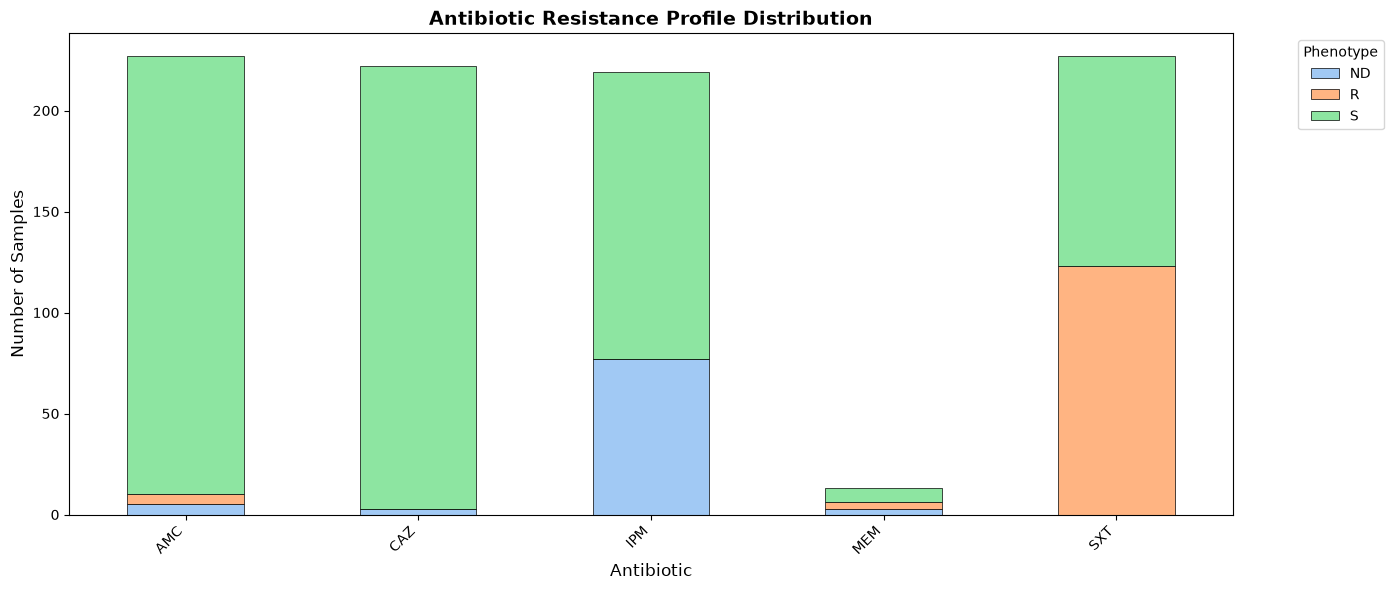


Summary Table:
Phenotype     ND      R      S
Antibiotic                    
AMC          5.0    5.0  217.0
CAZ          3.0    0.0  219.0
IPM         77.0    0.0  142.0
MEM          3.0    3.0    7.0
SXT          0.0  123.0  104.0


In [11]:
antibiotic_cols = [col for col in resistances_df.columns]

# Create a summary dataframe for visualization
data_for_plot = []
for antibiotic in antibiotic_cols:
    distribution = resistances_df[antibiotic].value_counts()
    for phenotype, count in distribution.items():
        data_for_plot.append({
            'Antibiotic': antibiotic,
            'Phenotype': phenotype,
            'Count': count
        })

summary_df = pd.DataFrame(data_for_plot)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot for stacking
pivot_df = summary_df.pivot(index='Antibiotic', columns='Phenotype', values='Count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, ax=ax, edgecolor='black', linewidth=0.5)

ax.set_title('Antibiotic Resistance Profile Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Antibiotic', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.legend(title='Phenotype', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('antibiotic_phenotype_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary Table:")
print(pivot_df)

We see that the only antibiotic that would make sense for a machine learning prediction is SXT. Let's focus on that one. 

In [12]:
# Select antibiotic for ML prediction 
target_antibiotic = 'SXT'

### **2.1 Filter feature matrix according to resistance profile**
Let's now go back to our feature matrix and make sure all samples have valid information for the SXT antibiotic. I will also create a binary category for that antibiotic (Susceptible = 0, Resistant = 1).

In [13]:
# Create binary target: S=0 (susceptible), R=1 (resistant)
SXT_profile = resistances_df[target_antibiotic].copy()

# Remove ND 
valid_samples = SXT_profile[SXT_profile.isin(['S', 'R'])].index
print(f"Valid samples: {len(valid_samples)} out of {len(SXT_profile)}")

# Filter feature matrix
snps_df = snps_df.loc[valid_samples]

# Convert resistance profile to int (1=Resistant, 0=Susceptible)
SXT_profile = (SXT_profile.loc[valid_samples] == 'R').astype(int) 

print(f"\nFinal dataset:")
print(f"Samples: {len(snps_df)}")
print(f"SNPs: {snps_df.shape[1]}")
print(f"\nSXT resistance distribution:\n{SXT_profile.value_counts()}")

Valid samples: 227 out of 227

Final dataset:
Samples: 227
SNPs: 78850

SXT resistance distribution:
SXT
1    123
0    104
Name: count, dtype: int64


## **3. Data exploration and data cleaning**
Now that we have our feature matrix and the resistance profile for all of the strains, let's perform some preliminary data cleaning on the feature matrix. 

## **3.1 Ensure Data Type consistency**
Let's first make sure that all of our data is in the format that we are expecting. The SNPs data should be binary and equal to 1 if the SNP is present or 0 if absent. 

In [14]:
print("Data types present in the feature matrix:")
snps_df.dtypes.value_counts()

Data types present in the feature matrix:


int64    78850
Name: count, dtype: int64

In [15]:
invalid = (~snps_df.isin([0, 1])).sum().sum()
print(f"{invalid} entries are different than 0 or 1")

0 entries are different than 0 or 1


We see that the SNP data contains only zeros and ones, as expected. 

### **3.2 Remove Low-Prevalence SNPs**
Let's now move to feature selection. I will first select only SNPs present in at least 2% and at most 98% of the data. 
SNPs present in less than 2% or more than 98% of samples don't provide predictive power.
- less than 2%: too rare (likely noise)
- more than 98%: nearly fixed (=> no variation to predict from)

In [16]:
# Calculate allele frequencies
snp_prevalence = snps_df.sum(axis=0) / len(snps_df) * 100  # % of samples with SNP of interest

print(f"SNP prevalence statistics:")
print(f"Mean: {snp_prevalence.mean():.2f}%")
print(f"Median: {snp_prevalence.median():.2f}%")
print(f"Min: {snp_prevalence.min():.2f}%")
print(f"Max: {snp_prevalence.max():.2f}%")

# Count SNPs in different frequency bins
print(f"\nSNP frequency distribution:")
print(f"<2%: {(snp_prevalence < 2).sum()}")
print(f"2-98%: {((snp_prevalence >= 2) & (snp_prevalence <= 98)).sum()}")
print(f">98%: {(snp_prevalence > 98).sum()}")

SNP prevalence statistics:
Mean: 14.60%
Median: 2.64%
Min: 0.44%
Max: 99.12%

SNP frequency distribution:
<2%: 36087
2-98%: 42562
>98%: 201


In [19]:
# Filter: keep SNPs present in 5-95% of samples
mask = (snp_prevalence >= 2) & (snp_prevalence <= 98)
snps_filt = snps_df[snps_df.columns[mask]].copy()

print(f"Original SNPs: {snps_df.shape[1]}")
print(f"Filtered SNPs: {snps_filt.shape[1]}")
print(f"Removed: {snps_df.shape[1] - snps_filt.shape[1]} ({(snps_df.shape[1] - snps_filt.shape[1])/snps_df.shape[1]*100:.1f}%)")

Original SNPs: 78850
Filtered SNPs: 42562
Removed: 36288 (46.0%)


### **3.3. Remove Duplicate SNPs**

I will now remove duplicated SNPs (If two SNPs are identical across all samples, I will keep only one).

In [20]:
# Find duplicate SNPs
snps_T = snps_filt.T
duplicates = snps_T.duplicated(keep='first')

print(f"Number of duplicated SNPs: {duplicates.sum()}")

# Remove duplicate SNPs
snps_unique = snps_filt.loc[:, ~duplicates].copy()

print(f"SNPs before: {snps_filt.shape[1]}")
print(f"SNPs after: {snps_unique.shape[1]}")
print(f"Removed: {snps_filt.shape[1] - snps_unique.shape[1]} SNPs")

Number of duplicated SNPs: 5672
SNPs before: 42562
SNPs after: 36890
Removed: 5672 SNPs


### **3.4. Linkage disequilibrium Pruning**
When SNPs are inherited together, they have a very high correlation. We can perform Linkage Disequilibrium pruning to keep only one representative SNP from each correlated cluster. 
I will set a threshold and remove any SNP that has a correlation above 99% with another SNP. I will always remove the SNP that has the least variance in a correlated pair. 

In [45]:
high_corr_pairs = []
snps_array = snps_unique.values.astype(np.float32)
n_snps = snps_array.shape[1]

# normalize for correlations
snps_norm = (snps_array - snps_array.mean(axis=0)) / (snps_array.std(axis=0) + 1e-10)

# Process in batches
batch_size = 1000
for batch_start in range(0, n_snps, batch_size):
    batch_end = min(batch_start + batch_size, n_snps)
    
    # Compute correlations for this batch against all SNPs
    batch = snps_norm[:, batch_start:batch_end]
    
    # Correlation = dot product of normalized data / n_samples
    corr = np.abs(np.dot(batch.T, snps_norm) / len(snps_norm))
    
    # Find pairs above threshold and save them in high_corr_pairs
    for i, snp_i_idx in enumerate(range(batch_start, batch_end)):
        for j in range(snp_i_idx + 1, n_snps):
            if corr[i, j] > 0.99:
                high_corr_pairs.append((
                    snps_unique.columns[snp_i_idx],
                    snps_unique.columns[j],
                    float(corr[i, j])
                ))
    
    print(f"Processed {batch_end}/{n_snps} SNPs. ({len(high_corr_pairs)} pairs found so far)")

print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")

Processed 500/36890 SNPs. (2 pairs found so far)
Processed 1000/36890 SNPs. (7 pairs found so far)
Processed 1500/36890 SNPs. (9 pairs found so far)
Processed 2000/36890 SNPs. (10 pairs found so far)
Processed 2500/36890 SNPs. (13 pairs found so far)
Processed 3000/36890 SNPs. (13 pairs found so far)
Processed 3500/36890 SNPs. (14 pairs found so far)
Processed 4000/36890 SNPs. (17 pairs found so far)
Processed 4500/36890 SNPs. (18 pairs found so far)
Processed 5000/36890 SNPs. (22 pairs found so far)
Processed 5500/36890 SNPs. (24 pairs found so far)
Processed 6000/36890 SNPs. (26 pairs found so far)
Processed 6500/36890 SNPs. (26 pairs found so far)
Processed 7000/36890 SNPs. (26 pairs found so far)
Processed 7500/36890 SNPs. (26 pairs found so far)
Processed 8000/36890 SNPs. (28 pairs found so far)
Processed 8500/36890 SNPs. (29 pairs found so far)
Processed 9000/36890 SNPs. (31 pairs found so far)
Processed 9500/36890 SNPs. (34 pairs found so far)
Processed 10000/36890 SNPs. (36 pai

In [46]:
# LD pruning. For each correlated pair, keep only one snp. 
snps_to_remove = set()

for snp1, snp2, corr in high_corr_pairs:
    var1 = snps_unique[snp1].var()
    var2 = snps_unique[snp2].var()
    
    if var1 < var2:
        snps_to_remove.add(snp1)
    else:
        snps_to_remove.add(snp2)

# Remove correlated SNPs
snps_ld = snps_unique.loc[:, ~snps_unique.columns.isin(snps_to_remove)].copy()

print(f"SNPs before: {snps_unique.shape[1]}")
print(f"SNPs after: {snps_ld.shape[1]}")
print(f"Removed: {len(snps_to_remove)} SNPs due to high correlation")

SNPs before: 36890
SNPs after: 36751
Removed: 139 SNPs due to high correlation


### **3.5. Select only SNPs Correlated with Resistance**
I will now filter the feature matrix to keep only SNPs that are correlated with the resistance profile. Other SNPs are likely not very informative for a machine learning algorithm. 

To do so, I will perform use **selectKBest** to select features significantly associated with resistance.

#### **3.5.1 Calculate Chi2 values**
I will first use selectKBest to calculate a chi2 score and a p-value for each feature. 

In [47]:
# Calculate F-scores for all features
selector_scoring = SelectKBest(score_func=chi2, k='all')
selector_scoring.fit(snps_ld.values, SXT_profile.values)

# Get scores for all features
feature_scores = selector_scoring.scores_
feature_pvalues = selector_scoring.pvalues_

# Create results dataframe
feature_importance = pd.DataFrame({
    "snp_feature": snps_ld.columns,
    "chi2": feature_scores,
    "p_value": feature_pvalues
})

feature_importance = feature_importance.sort_values("chi2", ascending=False)
feature_importance = feature_importance.dropna()

print(f'Total features scored: {len(feature_pvalues)}')
print(f'Significant features (p<0.05): {(feature_pvalues < 0.05).sum()}')
print(f'\nTop 20 features by chi2 value:')
print(feature_importance.head(20)[["snp_feature", "chi2", "p_value"]].to_string())

Total features scored: 36751
Significant features (p<0.05): 6121

Top 20 features by chi2 value:
                                            snp_feature       chi2   p_value
12588                    snp__NZ_AP028077.1_2542039_G_C  20.386681  0.000006
36082                    snp__NZ_AP028078.1_3041405_G_A  20.148819  0.000007
12589                  snp__NZ_AP028077.1_2542044_TGC_T  19.621717  0.000009
18914                     snp__NZ_AP028078.1_124660_T_C  19.621717  0.000009
28176                    snp__NZ_AP028078.1_1665837_G_A  18.860110  0.000014
1410                     snp__NZ_AP028077.1_236894_CA_C  18.481356  0.000017
25842                    snp__NZ_AP028078.1_1312066_C_T  18.262259  0.000019
35136                    snp__NZ_AP028078.1_2862120_T_C  18.253660  0.000019
18706                     snp__NZ_AP028078.1_105461_C_T  17.749833  0.000025
3351                      snp__NZ_AP028077.1_722228_G_A  17.583846  0.000027
28378                    snp__NZ_AP028078.1_1695139_A_G 

#### **3.5.2 Feature selection**
I will now keep only significant features (p-value smaller than 0.05). 

In [48]:
# Select significant features
sig_mask = (feature_pvalues < 0.05)
snps_selected = snps_ld.loc[:, sig_mask]

print(f'Original features: {snps_ld.shape[1]}')
print(f'Selected features: {snps_selected.shape[1]}')

Original features: 36751
Selected features: 6121


#### **3.5.3 Visualize top features**

/tmp/ipykernel_58219/1529874536.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[2.03866807e+01 4.05355002e+01 6.01572169e+01 ... 6.83903861e+04
 6.83903861e+04 6.83903861e+04]


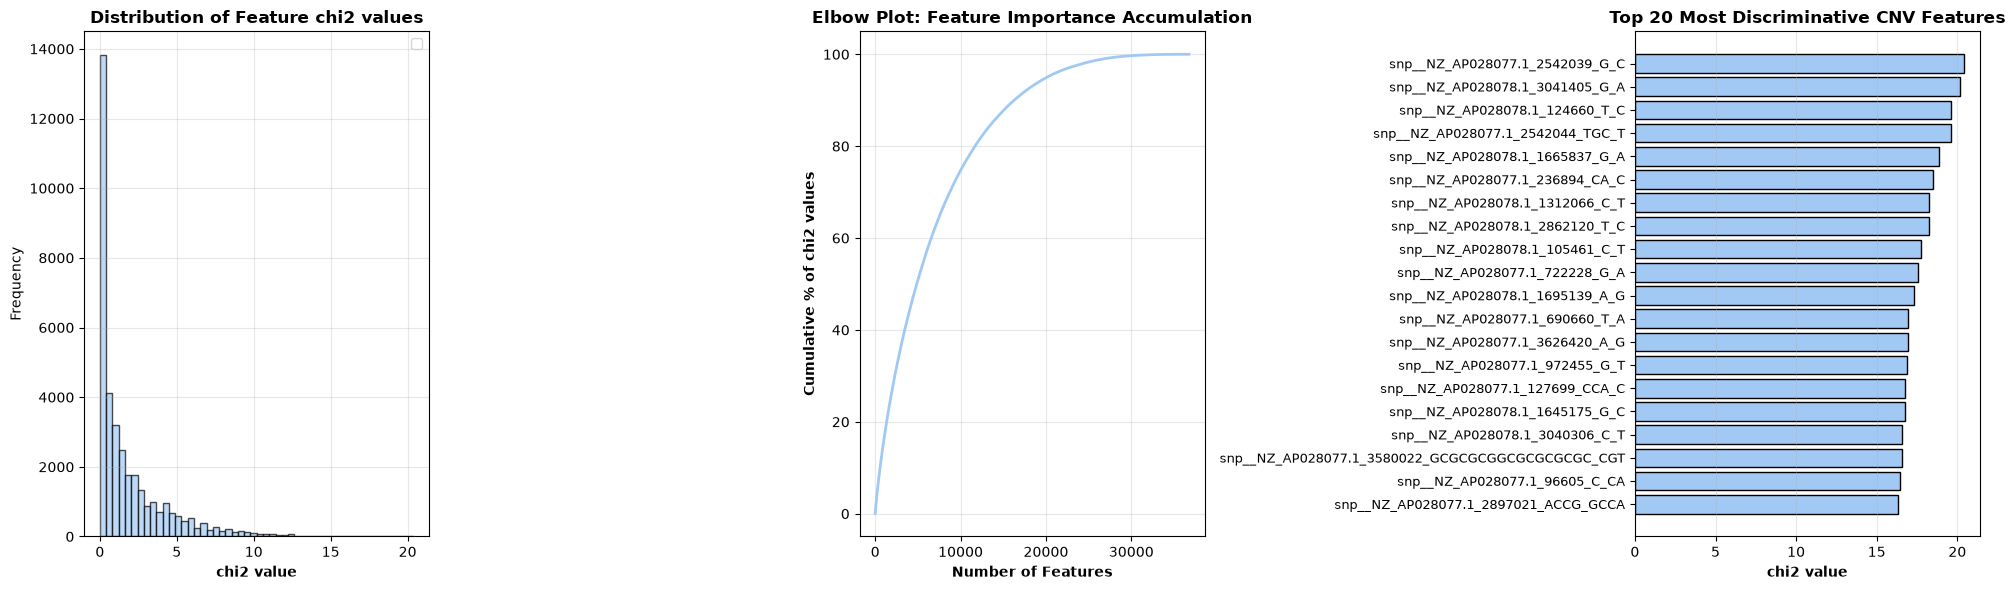

In [49]:
# Visualize top features and selection
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution of F-scores
ax = axes[0]
ax.hist(feature_importance['chi2'], bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("chi2 value", fontweight='bold')
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Feature chi2 values", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Elbow plot
cumsum_scores = np.cumsum(feature_importance['chi2'].values)
cumsum_scores_pct = 100 * cumsum_scores / cumsum_scores[-1]
print(cumsum_scores)
ax = axes[1]
ax.plot(range(1, len(cumsum_scores_pct)+1), cumsum_scores_pct, linewidth=2)
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cumulative % of chi2 values', fontweight='bold')
ax.set_title('Elbow Plot: Feature Importance Accumulation', fontweight='bold')
ax.grid(alpha=0.3)

# Top 20 features
ax = axes[2]
top20 = feature_importance.head(20).sort_values('chi2')
bars = ax.barh(range(len(top20)), top20['chi2'], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f for f in top20['snp_feature']], fontsize=9)
ax.set_xlabel('chi2 value', fontweight='bold')
ax.set_title(f'Top 20 Most Discriminative CNV Features', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/01_feature_selection_selectkbest.png", dpi=300, bbox_inches='tight')
plt.show()

## **4. Save the feature matrix**

In [50]:
# Save cleaned data for ML
# Features
snps_selected.to_csv(f'snps_cleaned_{target_antibiotic}.csv')
print(f"Saved features to: snps_cleaned_{target_antibiotic}.csv")

# Target
SXT_profile.to_csv(f'{target_antibiotic}.csv')

Saved features to: snps_cleaned_SXT.csv
